In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# First attempt 
change price and keep size equal

In [2]:
mid_price = 1000
steps_price = 5
steps_number = 99
bid_size = 100

In [3]:
# Start list of bid prices with best bid
bid_prices = [mid_price-steps_price]
# Start list of bid sizes
bid_sizes = [100]

for i in range(steps_number):
    # Create next best bid as previous bid - steps_price
    bid = bid_prices[i] - steps_price*(i/steps_number)
    bid_prices.append(bid)
    # Create corresponding bid_size
    bid_sizes.append(bid_size)

# Create df
bid_book = pd.DataFrame({'bid_price':bid_prices,'bid_size':bid_sizes})

# Add cumulative sum column
bid_book['cumulative_size'] = bid_book['bid_size'].cumsum()

In [4]:
bid_book

,bid_price,bid_size,cumulative_size
0,995.000000,100,100
1,995.000000,100,200
2,994.949495,100,300
3,994.848485,100,400
4,994.696970,100,500
...,...,...,...
95,769.494949,100,9600
96,764.696970,100,9700
97,759.848485,100,9800
98,754.949495,100,9900


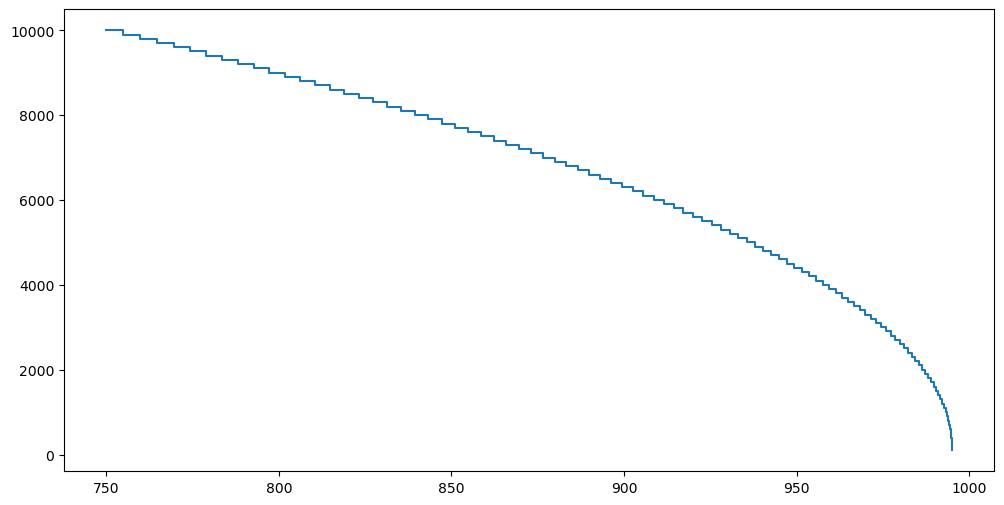

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
x = bid_book['bid_price']
y = bid_book['cumulative_size']
fig = plt.step(x,y)

Need to:

- define margin size (buy -x% of midprice, sell +y% of midprice)
- define price interval at which offers are made
- calculate necessary number of steps given price interval and margin size
- define formulae to calculate size of offer at preset price points
- Maybe define total size?
   
 or is it better to make all of equal size and change price intervals?

# Attempt 2
Define margin sizes, fixed price step difference  
Find number of steps, size of offers  

Should include 'padding' - define area to be shown and include those prices with size = 0

Include parameter: alpha & beta - How far from mid are first bid and ask prices

Change bid price to percentage

In [31]:
mid_price = 30_000
# Include spread from mid price before first bid (beta) or ask (alpha)
buy_margin, sell_margin = 0.005, 0.005 # don't name this margin
buy_depth, sell_depth = 2500, 2000
plot_margins = 0.05 #max(buy_margin, sell_margin)*2

step_difference = 1 # tick size (theta)

# v_p = bid/ask volume at specific price
# Cumulative bid volume = V_b
# Cumulative ask volume

In [32]:
buy_limit = mid_price - buy_margin*mid_price # name this min_buy_price
sell_limit = mid_price + sell_margin*mid_price # name this max_ask_price
print(buy_limit, sell_limit)

29850.0 30150.0


In [33]:
steps = int((plot_margins*mid_price)/step_difference)
steps

1500

In [34]:
sell_steps = int((sell_limit - mid_price)/step_difference)
buy_steps = int((mid_price - buy_limit)/step_difference)

print(buy_steps, sell_steps)

150 150


In [35]:
#linear_shape
# Buy side
buy_size = buy_depth/buy_steps
print(buy_size)

# Making list of prices and bid sizes
buy_prices = []
for i in range(steps):
    bid_price = mid_price - (i+1)*step_difference
    buy_prices.append(bid_price)

buy_sizes = []
for i in range(steps):
    if i < buy_steps:
        buy_sizes.append(buy_size)
    else:
        buy_sizes.append(0)


# sell side
sell_size = sell_depth/sell_steps
print(sell_size)

# Making list of prices and bid sizes
sell_prices = []
for i in range(steps):
    bid_price = mid_price + (i+1)*step_difference
    sell_prices.append(bid_price)

sell_sizes = []
for i in range(steps):
    if i < sell_steps:
        sell_sizes.append(sell_size)
    else:
        sell_sizes.append(0)

16.666666666666668
13.333333333333334


In [36]:
sell_sizes

[13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333333334,
 13.333333333

In [37]:
# Create orderbook df
buy_book = pd.DataFrame({'bid_price':buy_prices,'bid_size':buy_sizes})
sell_book = pd.DataFrame({'bid_price':sell_prices, 'bid_size':sell_sizes})

# Add cumulative sum column
buy_book['cumulative_size'] = buy_book['bid_size'].cumsum()
sell_book['cumulative_size'] = sell_book['bid_size'].cumsum()

In [38]:
buy_book.loc[140:160]

,bid_price,bid_size,cumulative_size
140,29859,16.666667,2350.000000
141,29858,16.666667,2366.666667
142,29857,16.666667,2383.333333
143,29856,16.666667,2400.000000
144,29855,16.666667,2416.666667
145,29854,16.666667,2433.333333
146,29853,16.666667,2450.000000
147,29852,16.666667,2466.666667
148,29851,16.666667,2483.333333
149,29850,16.666667,2500.000000


In [39]:
sell_book.loc[140:160]

,bid_price,bid_size,cumulative_size
140,30141,13.333333,1880.000000
141,30142,13.333333,1893.333333
142,30143,13.333333,1906.666667
143,30144,13.333333,1920.000000
144,30145,13.333333,1933.333333
145,30146,13.333333,1946.666667
146,30147,13.333333,1960.000000
147,30148,13.333333,1973.333333
148,30149,13.333333,1986.666667
149,30150,13.333333,2000.000000


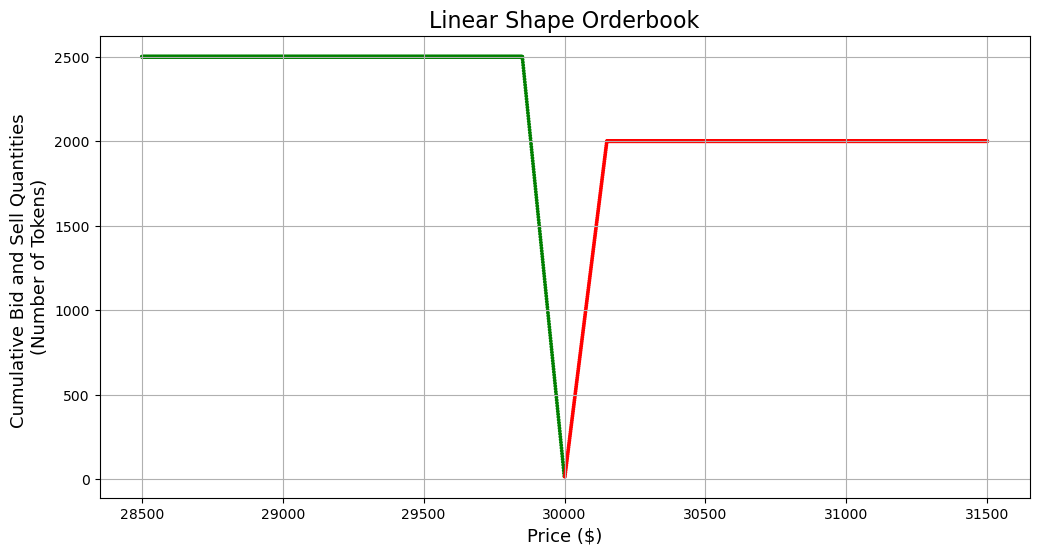

In [40]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
buy_book.sort_values(by=['bid_price'], inplace = True)
x = pd.concat([buy_book['bid_price'], sell_book['bid_price']],ignore_index=True)
y = pd.concat([buy_book['cumulative_size'], sell_book['cumulative_size']], ignore_index=True)
colors = np.where(x<mid_price, 'g', 'r')


plt.scatter(x,y, c=colors, marker='o', s=3)
plt.title("Linear Shape Orderbook", fontsize='16')
plt.xlabel("Price ($)",fontsize='13')
plt.ylabel("Cumulative Bid and Sell Quantities \n(Number of Tokens)",fontsize='13')
plt.grid()